In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

# Step 1: GBM Price Process + Bid/Ask Spread

Simulate a microsecond mid-price via GBM, then derive bid/ask using a dynamic spread that widens with instantaneous volatility.

In [2]:
def simulate_gbm(
    S0: float = 100.0,
    mu: float = 0.05,          # annualised drift
    sigma: float = 0.20,       # annualised vol
    T_seconds: float = 1,#3600.0, # simulation horizon in seconds (1 hour)
    dt_us: float = 1.0,        # tick size in microseconds
    seed: int = 42,
) -> pd.DataFrame:
    """
    Euler-Maruyama GBM on a microsecond clock.
    Returns a DataFrame with columns: time_us, mid
    """
    rng = np.random.default_rng(seed)

    dt_s = dt_us * 1e-6                         # µs → seconds
    dt_y = dt_s / (252 * 6.5 * 3600)           # seconds → trading-year fraction
    n    = int(T_seconds / dt_s)

    dW  = rng.standard_normal(n) * np.sqrt(dt_y)
    log_returns = (mu - 0.5 * sigma**2) * dt_y + sigma * dW

    log_prices = np.empty(n + 1)
    log_prices[0] = np.log(S0)
    np.cumsum(log_returns, out=log_prices[1:])
    log_prices[1:] += log_prices[0]

    mid       = np.exp(log_prices)
    time_us   = np.arange(n + 1, dtype=np.float64) * dt_us

    return pd.DataFrame({"time_us": time_us, "mid": mid})


df = simulate_gbm()
print(f"Ticks: {len(df):,}  |  Mid range: {df.mid.min():.4f} – {df.mid.max():.4f}")
df.head()

Ticks: 1,000,001  |  Mid range: 99.9913 – 100.0026


,time_us,mid
0,0.0,100.000000
1,1.0,100.000003
2,2.0,99.999994
3,3.0,100.000000
4,4.0,100.000008


In [4]:
def add_spread(
    df: pd.DataFrame,
    s0_bps: float = 2.0,   # base half-spread in bps
    kappa: float = 5.0,    # vol sensitivity: spread widens when vol spikes
    window_us: int = 10_000,  # rolling window for realised vol (10ms)
) -> pd.DataFrame:
    """
    Derive bid/ask from mid using a dynamic half-spread:
        half_spread = (s0_bps/10000) * mid  +  kappa * realised_vol_of_mid

    realised_vol is a rolling std of log-returns over `window_us` ticks.
    """
    df = df.copy()

    log_ret = np.log(df["mid"]).diff()
    roll_vol = log_ret.rolling(window=window_us, min_periods=1).std().fillna(0.0)

    base_half   = (s0_bps / 10_000) * df["mid"]
    dyn_half    = kappa * roll_vol * df["mid"]
    half_spread = base_half + dyn_half

    df["half_spread"] = half_spread
    df["bid"]         = df["mid"] - half_spread
    df["ask"]         = df["mid"] + half_spread
    df["spread_bps"]  = (2 * half_spread / df["mid"]) * 10_000

    return df


df = add_spread(df)
print(f"Spread — mean: {df.spread_bps.mean():.2f} bps  |  max: {df.spread_bps.max():.2f} bps")
df[["time_us", "bid", "mid", "ask", "spread_bps"]].head(10)

Spread — mean: 4.01 bps  |  max: 4.01 bps


,time_us,bid,mid,ask,spread_bps
0,0.0,99.980000,100.000000,100.020000,4.000000
1,1.0,99.980003,100.000003,100.020003,4.000000
2,2.0,99.979955,99.999994,100.020033,4.007831
3,3.0,99.979962,100.000000,100.020039,4.007677
4,4.0,99.979971,100.000008,100.020045,4.007357
5,5.0,99.979940,99.999992,100.020043,4.010279
6,6.0,99.979932,99.999981,100.020031,4.009914
7,7.0,99.979936,99.999982,100.020028,4.009189
8,8.0,99.979937,99.999980,100.020022,4.008507
9,9.0,99.979939,99.999979,100.020019,4.007999


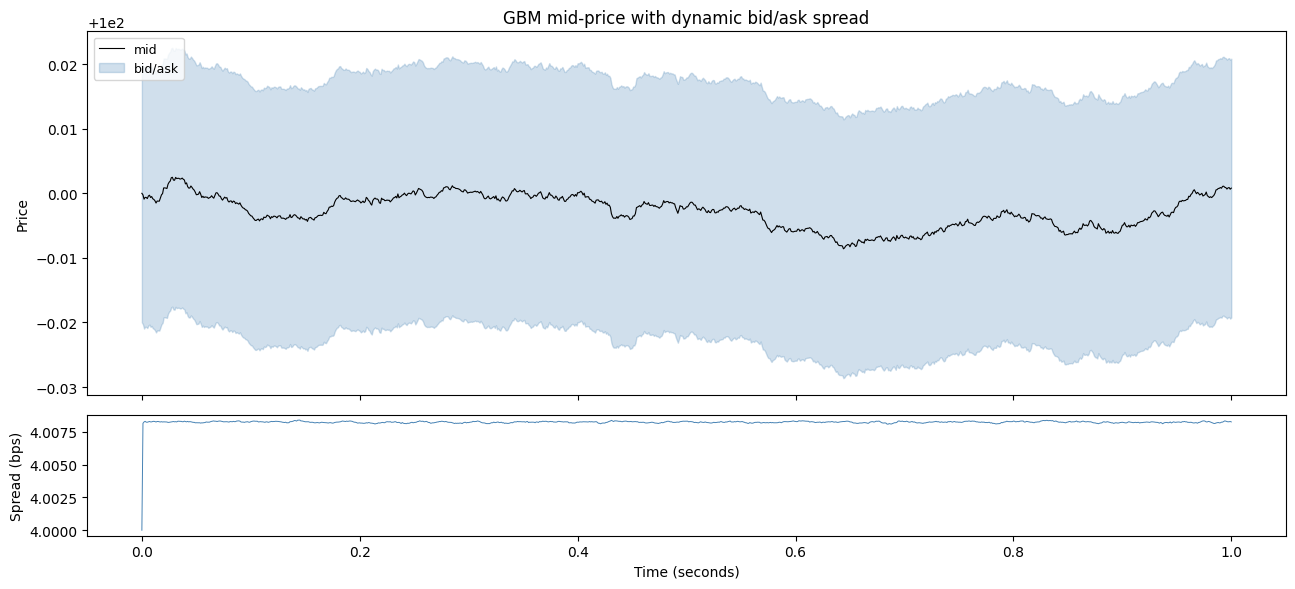

In [5]:
# --- visualise a 1-second slice (1,000,000 ticks → downsample for plotting) ---
slice_s   = 10         # seconds to plot
every_nth = 1_000      # plot every Nth tick (1ms resolution is enough for the eye)

view = df[df["time_us"] <= slice_s * 1e6].iloc[::every_nth]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(view["time_us"] / 1e6, view["mid"], color="black", lw=0.8, label="mid")
ax1.fill_between(view["time_us"] / 1e6, view["bid"], view["ask"],
                 alpha=0.25, color="steelblue", label="bid/ask")
ax1.set_ylabel("Price")
ax1.legend(loc="upper left", fontsize=9)
ax1.set_title("GBM mid-price with dynamic bid/ask spread")

ax2.plot(view["time_us"] / 1e6, view["spread_bps"], color="steelblue", lw=0.7)
ax2.set_ylabel("Spread (bps)")
ax2.set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()